# Prompt chaining 
It is a prompt engineering technique that breaks a complex task into a sequence of smaller, interconnected subtasks, where the output of one prompt serves as the input for the next.  Instead of relying on a single, overloaded prompt to perform multiple cognitive steps, this method guides the Large Language Model (LLM) through a structured, modular workflow.

In [1]:
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3.6-27b") 
result=model.invoke("hello")
print(result.content)

e:\Agents\agent\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



<think>
Hmm, the user just said "hello" - a simple greeting. This is a straightforward case where the expected response is just a friendly acknowledgment. 

I should keep it warm and open-ended to encourage further conversation. A simple "Hello!" with a welcoming question about how I can help would work well here. 

No need for complexity since the user hasn't specified any request yet. Just maintain a helpful tone and leave the next step to them.
</think>

Hello! 👋 How can I assist you today?


In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

### Graph state
class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

### Nodes
def generate_story(state:State):
    msg=model.invoke(f"Write a one sentence story about {state['topic']}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state['story'] or "!" in state['story']:
        return "Fail"
    return "Pass"

def improve_story(state:State):
    msg=model.invoke(f"Improve the story furthermore and enhance with vivid details: {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg=model.invoke(f"Add a twist to this story premise and make it mind-blowing: {state['improved_story']}")
    return {"final_story":msg.content}

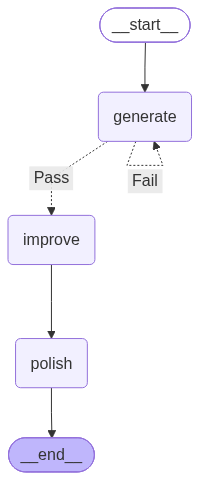

In [15]:
## graph
graph=StateGraph(State)
graph.add_node("generate",generate_story)
graph.add_node("improve",improve_story)
graph.add_node("polish",polish_story)

## add edges
graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict,{"Pass":"improve","Fail":"generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)

# Compile the graph
compiled_graph=graph.compile()

# visualize
graph_image=compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [16]:
## run
state={"topic":"sotry of a poor boy"}
result=compiled_graph.invoke(state)
result

{'topic': 'sotry of a poor boy',
 'story': '\n<think>\nThinking Process:\n\n1.  **Deconstruct the request:**\n    *   Topic: Story of a poor boy.\n    *   Format: One sentence.\n\n2.  **Brainstorming core themes/imagery:**\n    *   Poverty: Hunger, cold, rags, dreams, contrast, hope, struggle, transformation.\n    *   Boy: Youth, innocence, potential, resilience.\n    *   Arc: Needs a beginning, middle, and end (or a poignant moment) within one sentence.\n\n3.  **Drafting - Attempt 1 (Literal/Descriptive):**\n    *   The poor boy walked through the snow looking for food until he found a coin.\n    *   *Critique:* Too boring, lacks emotional resonance.\n\n4.  **Drafting - Attempt 2 (Metaphorical/Poetic):**\n    *   He traded his rags for dreams and climbed out of the mud.\n    *   *Critique:* A bit cliché. "Traded rags for dreams" is overused.\n\n5.  **Drafting - Attempt 3 (Focus on contrast/hope):**\n    *   With empty pockets but a heart full of stars, the boy built a ladder to the cl

Automated Self-Correction: Unlike static chains, it allows the AI to loop back and fix its own mistakes. If the "Improve" node detects weak logic, it can route the task back to "Generate" automatically without human intervention.

Specialized Focus: Each node handles one specific job (e.g., just drafting, just fact-checking, just styling). This prevents the "context dilution" that happens when asking one prompt to do everything, resulting in higher quality output.

Decision Making: The workflow isn't fixed. It can branch based on content needs (e.g., skip "Polish" for a technical report but require it for a marketing email), saving tokens and time.
State Persistence: The system remembers every iteration. When the AI loops back, it sees exactly what it tried before and why 